In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_excel('Dry_Bean_Dataset.xlsx')

Общая информация
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 


None

Статистика


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


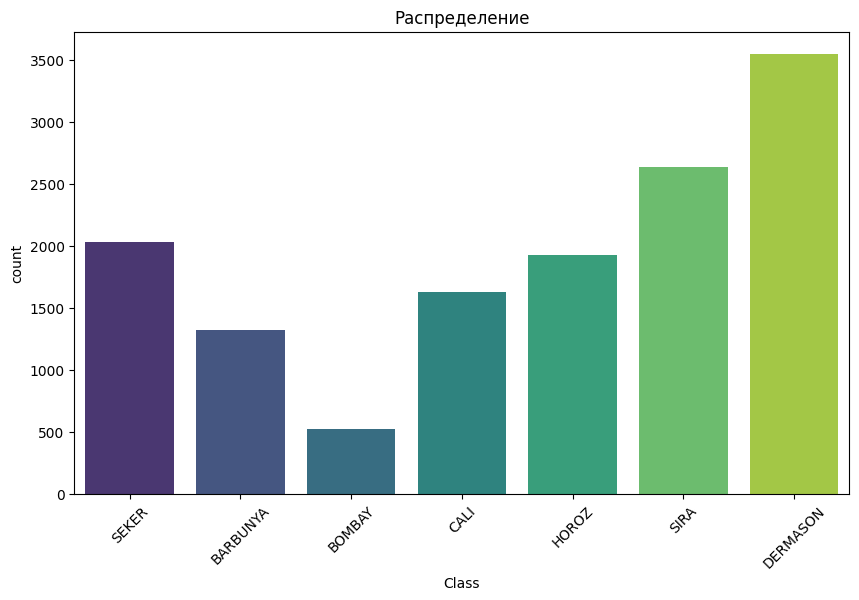

In [57]:
print("Общая информация")
display(df.info())
print("Статистика")
display(df.describe())

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Class', palette='viridis', hue='Class', legend=False)
plt.title('Распределение')
plt.xticks(rotation=45)
plt.show()

# Краткий обзор данных
* 13,611 записей.
* 16 геометрических признаков
* Задача: классификация зерна по одному из 7 сортов.
* пропуски отсутствуют

#Разделение и Масштабирование

In [58]:
if 'df' in locals():
    X = df.drop('Class', axis=1)
    y = df['Class']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

Проверка различных конфигураций

In [59]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17 ,19, 20],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, n_jobs=-1, verbose=1)
if 'X_train_scaled' in locals():
    grid_search.fit(X_train_scaled, y_train)
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучшая точность CV: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 20, 'weights': 'distance'}
Лучшая точность CV: 0.9274


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [0.91743163 0.91743147 0.9212891  0.92229933 0.9239529  0.92496325
 0.92413676 0.92505525 0.92395328 0.92514724 0.92450424 0.92615743
 0.92413706 0.92533111 0.92560638 0.9264332  0.92624955 0.92707621
 0.92652512 0.92744352        nan 0.91715645        nan 0.92165696
        nan 0.92266693        nan 0.92294271        nan 0.92367725
        nan 0.92386086        nan 0.92441195        nan 0.92441216
        nan 0.92432037        nan 0.92413664 0.91743163 0.91743147
 0.9212891  0.92229933 0.9239529  0.92496325 0.92413676 0.92505525
 0.92395328 0.92514724 0.92450424 0.92615743 0.92413706 0.92533111
 0.92560638 0.9264332  0.92624955 0.92707621 0.92652512 0.92744352]
  warnings.warn(


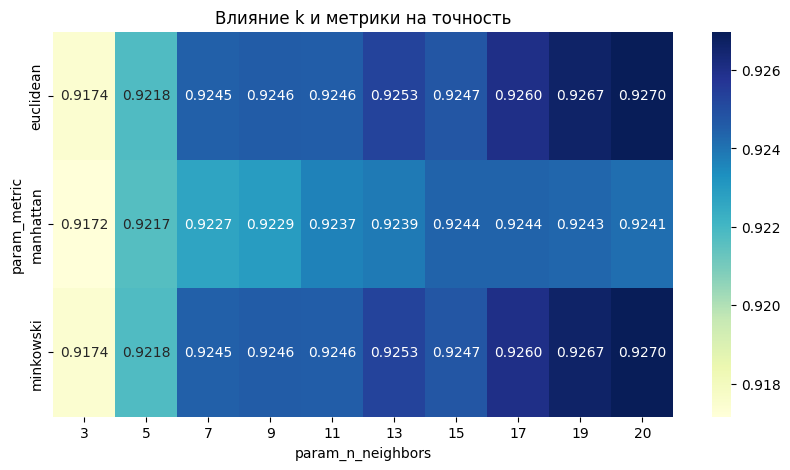

In [60]:
if 'grid_search' in locals():
    cv_res = pd.DataFrame(grid_search.cv_results_)
    pivot = cv_res.pivot_table(index='param_metric', columns='param_n_neighbors', values='mean_test_score', aggfunc='mean')

    plt.figure(figsize=(10, 5))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu')
    plt.title('Влияние k и метрики на точность')
    plt.show()

In [61]:
param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

knn = KNeighborsClassifier()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

grid_search.fit(X_train_scaled, y_train)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая точность на кросс-валидации: {grid_search.best_score_:.4f}")

display(pd.DataFrame(grid_search.cv_results_)[['param_n_neighbors', 'param_weights', 'param_metric', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False).head(10))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Лучшие параметры: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}
Лучшая точность на кросс-валидации: 0.9253


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [0.91743163 0.91743147 0.9212891  0.92229933 0.9239529  0.92496325
 0.92395328 0.92514724 0.92413706 0.92533111        nan 0.91715645
        nan 0.92165696        nan 0.92266693        nan 0.92367725
        nan 0.92441195 0.91743163 0.91743147 0.9212891  0.92229933
 0.9239529  0.92496325 0.92395328 0.92514724 0.92413706 0.92533111]
  warnings.warn(


,param_n_neighbors,param_weights,param_metric,mean_test_score
9,15,distance,euclidean,0.925331
29,15,distance,minkowski,0.925331
27,11,distance,minkowski,0.925147
7,11,distance,euclidean,0.925147
5,7,distance,euclidean,0.924963
25,7,distance,minkowski,0.924963
19,15,distance,manhattan,0.924412
28,15,uniform,minkowski,0.924137
8,15,uniform,euclidean,0.924137
26,11,uniform,minkowski,0.923953


#Лучшая модель
На основании лучших признаков и параметров получаем следующую модель

Результат лучшей модели
              precision    recall  f1-score   support

    BARBUNYA       0.97      0.88      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.93      0.95      0.94       326
    DERMASON       0.91      0.90      0.91       709
       HOROZ       0.96      0.95      0.95       386
       SEKER       0.94      0.95      0.94       406
        SIRA       0.84      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.94      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



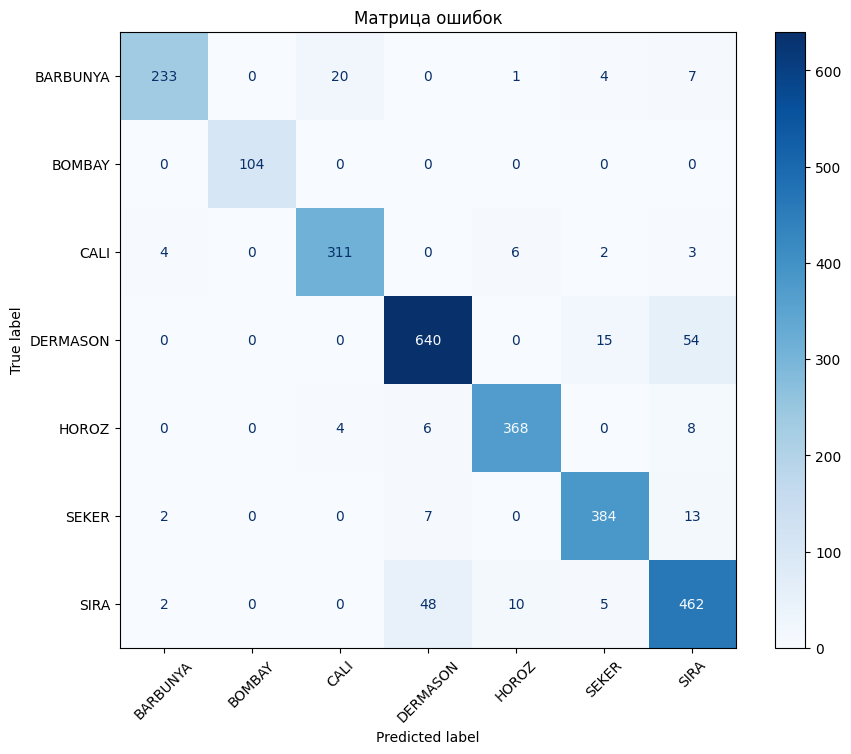

In [62]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

print("Результат лучшей модели")
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(best_model, X_test_scaled, y_test, cmap='Blues', ax=ax, xticks_rotation=45)
plt.title('Матрица ошибок')
plt.show()

#Сравнение различных параметров

/tmp/ipykernel_408/3408621517.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Этап', y='Точность', palette='magma')


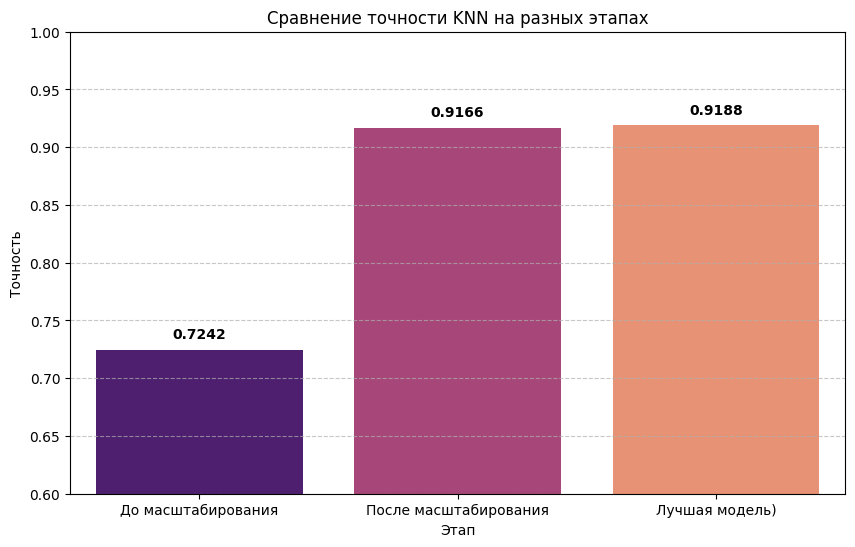

,Этап,Точность
0,До масштабирования,0.724201
1,После масштабирования,0.916636
2,Лучшая модель),0.918840


In [64]:
accuracy_data = {
    'Этап': ['До масштабирования', 'После масштабирования', 'Лучшая модель)'],
    'Точность': [acc_raw, acc_scaled, accuracy_score(y_test, y_pred)]
}

comparison_df = pd.DataFrame(accuracy_data)

plt.figure(figsize=(10, 6))
sns.barplot(data=comparison_df, x='Этап', y='Точность', palette='magma')
plt.ylim(0.6, 1.0)
plt.title('Сравнение точности KNN на разных этапах')

for i, val in enumerate(comparison_df['Точность']):
    plt.text(i, val + 0.01, f'{val:.4f}', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

display(comparison_df)

#Вывод
Таким образом масштабирование сильно улучшает точность, а наша лучшая модель имеет не самую лучшую точность.